# 5-Minute High-Frequency Volatility Analysis

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('data/IBM.csv')   # expects header: date, time, price

# Parse datetime: zero-pad time to 4 digits (e.g. 935 to 0935)
df['datetime'] = pd.to_datetime(
    df['date'].astype(str) + df['time'].astype(str).str.zfill(4),
    format='%Y%m%d%H%M'
)

print(f"Total rows : {len(df)}")
print(f"Date range : {df['datetime'].min()} -> {df['datetime'].max()}")
df.head(10)

Total rows : 154596
Date range : 2007-01-03 09:35:00 -> 2014-12-12 16:00:00


,date,time,price,datetime
0,20070103,935,96.89,2007-01-03 09:35:00
1,20070103,940,97.45,2007-01-03 09:40:00
2,20070103,945,97.78,2007-01-03 09:45:00
3,20070103,950,98.05,2007-01-03 09:50:00
4,20070103,955,98.09,2007-01-03 09:55:00
5,20070103,1000,97.87,2007-01-03 10:00:00
6,20070103,1005,98.00,2007-01-03 10:05:00
7,20070103,1010,97.94,2007-01-03 10:10:00
8,20070103,1015,97.93,2007-01-03 10:15:00
9,20070103,1020,97.94,2007-01-03 10:20:00


## Build Returns and Timestamps

Each trading day has `n + 1 = 78` price observations → `n = 77` log-returns.  
Returns are scaled to percentages: `r = 100 × Δlog(price)`.

In [ ]:
n = 77
T = len(df) // (n + 1)    # number of trading days
delta_n = 1.0 / n

prices_all = df['price'].values.astype(float)
datetime_all = df['datetime'].values

stk = np.zeros(n * T)          # intraday returns
dt_ret = np.empty(n * T, dtype='datetime64[ns]')   # timestamp per return

for t in range(T):
    id_full = np.arange(t * (n + 1), t * (n + 1) + (n + 1))   # n+1 prices
    idr = np.arange(t * n, t * n + n)                       # n returns

    stk[idr] = 100 * np.diff(np.log(prices_all[id_full]))
    dt_ret[idr] = datetime_all[id_full[1:]]   # timestamp = end of each interval

# One timestamp per day (first return of each day) — used for daily plots
YMD_TV = pd.DatetimeIndex(dt_ret[::n])

print(f"Trading days T = {T},  total returns = {len(stk)}")
print(f"Date range     : {YMD_TV[0].date()} -> {YMD_TV[-1].date()}")

Trading days T = 1982,  total returns = 152614
Date range     : 2007-01-03 -> 2014-12-12


In [6]:
alpha_J = 4.5       # jump-truncation threshold multiplier
# delta_n already defined above as 1/n

## Diurnal (Time-of-Day) Variation

Estimates intraday seasonality in volatility using a bipower-type average
across all days at each intraday interval `k`.
The first interval copies its neighbour (edge-case fix).

mean(tods) = 1.000000   (should be 1.0)


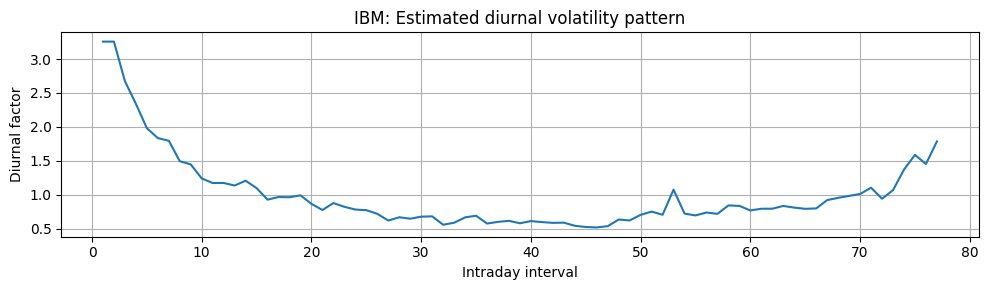

In [ ]:
mBVd = np.zeros(n)

for k in range(1, n): 
    IDa = np.arange(k, (T - 1) * n + k + 1, n)
    IDb = IDa - 1
    mBVd[k] = (np.pi / 2) * np.mean(np.abs(stk[IDa]) * np.abs(stk[IDb]))

mBVd[0] = mBVd[1]   # edge-case: copy neighbour

tods = (mBVd / mBVd.sum()) / delta_n
print(f"mean(tods) = {tods.mean():.6f}   (should be 1.0)")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.arange(1, n + 1), tods)
ax.set_xlabel('Intraday interval')
ax.set_ylabel('Diurnal factor')
ax.set_title('IBM: Estimated diurnal volatility pattern')
plt.tight_layout()
plt.show()

## Bipower Variation (BV)

Daily bipower variation is a jump-robust estimator of integrated variance:

$$\text{BV}_t = \frac{\pi}{2} \cdot \frac{n}{n-1} \sum_{i=2}^{n} |r_{t,i-1}| \cdot |r_{t,i}|$$

In [ ]:
BVs = np.zeros(T)

for t in range(T):
    idx1 = np.arange(t * n, t * n + n - 1)
    idx2 = idx1 + 1
    BVs[t] = (np.pi / 2) * n / (n - 1) * np.dot(np.abs(stk[idx1]), np.abs(stk[idx2]))

print(f"BV — mean: {BVs.mean():.4f},  min: {BVs.min():.4f},  max: {BVs.max():.4f}")

BV — mean: 1.5441,  min: 0.0888,  max: 75.2484


## Jump-Robust Truncated Variation (TV)

Returns larger than `α_J × √(diurnal × BV) × Δn^0.49` are classified as jumps and excluded.  
TV is then the sum of squared truncated returns.  
`TV_asym` provides the asymptotic standard error (used in the theoretical CI).

In [ ]:
TV = np.zeros(T)
TV_asym = np.zeros(T)

for t in range(T):
    id_ = np.arange(t * n, (t + 1) * n)
    thresh = alpha_J * np.sqrt(tods * BVs[t]) * delta_n ** 0.49
    keep_s = np.abs(stk[id_]) <= thresh
    tmp = stk[id_] * keep_s

    TV[t] = np.sum(tmp ** 2)
    TV_asym[t] = np.sqrt(np.sum(tmp ** 4) * 2 / 3)

print(f"TV — mean: {TV.mean():.4f},  min: {TV.min():.4f},  max: {TV.max():.4f}")

TV — mean: 1.5861,  min: 0.0994,  max: 70.2088


## Bootstrap Confidence Intervals

A block bootstrap (block size `k_n = 11`) is applied within each day to construct
empirical 95% CIs for TV.  
`Nsim = 100` simulations per day (increase for smoother CIs at the cost of runtime).

In [ ]:
k_n = 11
M = n // k_n
print(f"Block size k_n = {k_n}, number of blocks M = {M}")

TVq = np.zeros((T, 2))    # [lower 2.5%, upper 97.5%]
rng = np.random.default_rng(42)

for t in range(T):
    id_ = np.arange(t * n, (t + 1) * n)
    thresh = alpha_J * np.sqrt(tods * BVs[t]) * delta_n ** 0.49
    keep_s = np.abs(stk[id_]) <= thresh
    rc = keep_s * stk[id_]

    Nsim = 100
    TVsim = np.zeros(Nsim)

    for j in range(Nsim):
        S = np.zeros(M)
        for K in range(M):
            blk_idx = np.arange(K * k_n, K * k_n + k_n)
            U = rng.random(k_n)
            idS = (np.ceil(U * k_n) - 1).astype(int)
            idd = blk_idx[idS]
            S[K] = np.sum(rc[idd] ** 2)
        TVsim[j] = np.sum(S)

    TVq[t, :] = np.quantile(TVsim, [0.025, 0.975])

print("Bootstrap complete.")

Block size k_n = 11, number of blocks M = 7
Bootstrap complete.


## Plot — Annualised Volatility with Confidence Intervals

**Top panel**: Theoretical (asymptotic) 95% CI  
**Bottom panel**: Bootstrap 95% CI

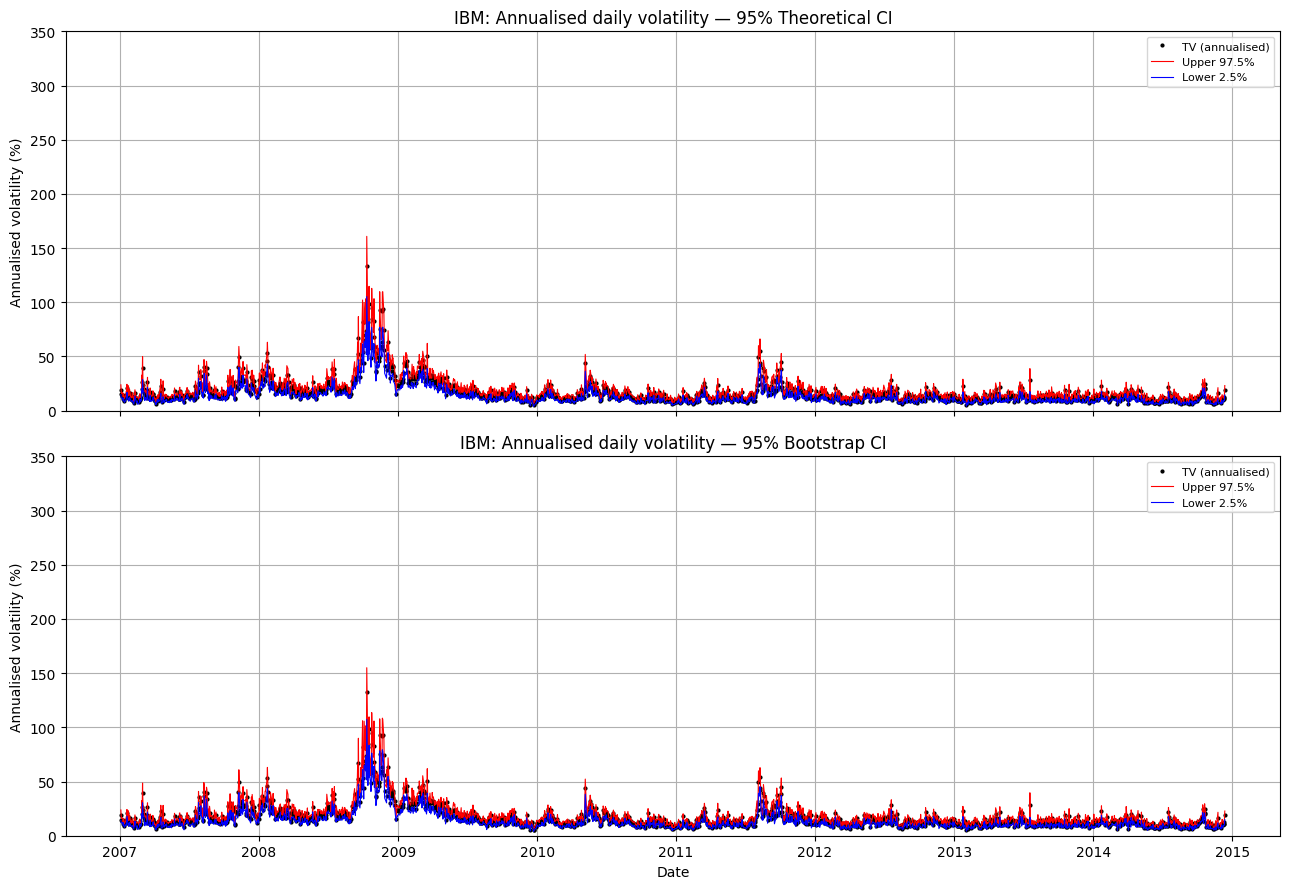

In [11]:
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

x_dates = YMD_TV.to_pydatetime()
ann_vol = np.sqrt(TV * 252)
ci_half = 1.96 * np.sqrt(252) / 2 / np.sqrt(TV) * TV_asym

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Theoretical CI
ax = axes[0]
ax.plot(x_dates, ann_vol,           '.k', markersize=4, label='TV (annualised)')
ax.plot(x_dates, ann_vol + ci_half, 'r-', linewidth=0.8, label='Upper 97.5%')
ax.plot(x_dates, ann_vol - ci_half, 'b-', linewidth=0.8, label='Lower 2.5%')
ax.set_ylim(0, 350)
ax.set_ylabel('Annualised volatility (%)')
ax.set_title('IBM: Annualised daily volatility — 95% Theoretical CI')
ax.legend(fontsize=8, loc='upper right')

# Bootstrap CI
ax = axes[1]
ax.plot(x_dates, ann_vol,                      '.k', markersize=4, label='TV (annualised)')
ax.plot(x_dates, np.sqrt(TVq[:, 1] * 252),    'r-', linewidth=0.8, label='Upper 97.5%')
ax.plot(x_dates, np.sqrt(TVq[:, 0] * 252),    'b-', linewidth=0.8, label='Lower 2.5%')
ax.set_ylim(0, 350)
ax.set_ylabel('Annualised volatility (%)')
ax.set_xlabel('Date')
ax.set_title('IBM: Annualised daily volatility — 95% Bootstrap CI')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

## Plot — Theoretical vs Bootstrap CI Width Comparison

Points on the 45° line indicate perfect agreement between the two CI methods.  
Deviations reveal days where the asymptotic approximation under- or over-estimates uncertainty.

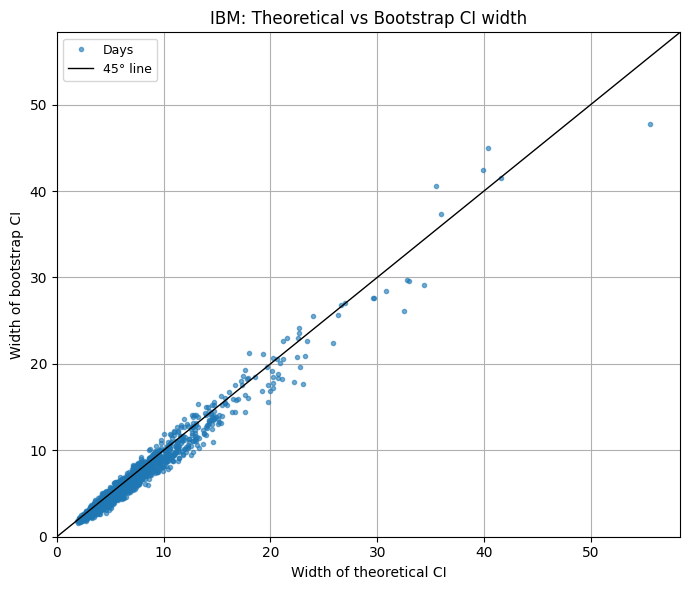

In [12]:
xx = 1.96 * np.sqrt(252) / 2 / np.sqrt(TV) * TV_asym * 2   # theoretical width
yy = np.sqrt(TVq[:, 1] * 252) - np.sqrt(TVq[:, 0] * 252)   # bootstrap width

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(xx, yy, '.', alpha=0.6, label='Days')
lim = max(xx.max(), yy.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k-', linewidth=1, label='45° line')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel('Width of theoretical CI')
ax.set_ylabel('Width of bootstrap CI')
ax.set_title('IBM: Theoretical vs Bootstrap CI width')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()